# Titanic Dataset - Exploratory Data Analysis and Baseline Modeling
This notebook performs an end-to-end analysis of the Titanic dataset: data inspection, cleaning, exploratory visualization, feature preparation, logistic regression training, and model evaluation.

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Plot style configuration
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)

# Load the Titanic dataset from seaborn
df_raw = sns.load_dataset('titanic')
df = df_raw.copy()

print('First 5 rows of the raw dataset:')
display(df.head())

print(f"\nDataset shape: {df.shape[0]} rows x {df.shape[1]} columns")
print('\nData types:')
display(df.dtypes.to_frame(name='dtype'))

First 5 rows of the raw dataset:


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True



Dataset shape: 891 rows x 15 columns

Data types:


,dtype
survived,int64
pclass,int64
sex,object
age,float64
sibsp,int64
parch,int64
fare,float64
embarked,object
class,category
who,object


In [13]:
# 1) Missing values overview
print('Missing values per column (raw):')
print(df.isnull().sum().sort_values(ascending=False))

# 2) Basic cleaning
cols_to_drop = ['deck', 'embark_town', 'alive', 'class', 'who', 'adult_male']
df = df.drop(columns=cols_to_drop)

# 3) Impute missing values
df['age'] = df['age'].fillna(df['age'].median())
df['embarked'] = df['embarked'].fillna(df['embarked'].mode()[0])

# 4) Encode categorical variables
df['sex'] = df['sex'].map({'male': 0, 'female': 1})
df = pd.get_dummies(df, columns=['embarked'], drop_first=True, dtype=int)

print('\nMissing values after cleaning:')
print(df.isnull().sum().sum())

Missing values per column (raw):
deck           688
age            177
embarked         2
embark_town      2
sex              0
pclass           0
survived         0
fare             0
parch            0
sibsp            0
class            0
adult_male       0
who              0
alive            0
alone            0
dtype: int64

Missing values after cleaning:
0


In [14]:
print('First 5 rows after preprocessing:')
display(df.head())

print('\nSummary statistics (numeric features):')
display(df.describe().T)

First 5 rows after preprocessing:


,survived,pclass,sex,age,sibsp,parch,fare,alone,embarked_Q,embarked_S
0,0,3,0,22.0,1,0,7.2500,False,0,1
1,1,1,1,38.0,1,0,71.2833,False,0,0
2,1,3,1,26.0,0,0,7.9250,True,0,1
3,1,1,1,35.0,1,0,53.1000,False,0,1
4,0,3,0,35.0,0,0,8.0500,True,0,1



Summary statistics (numeric features):


,count,mean,std,min,25%,50%,75%,max
survived,891.0,0.383838,0.486592,0.00,0.0000,0.0000,1.0,1.0000
pclass,891.0,2.308642,0.836071,1.00,2.0000,3.0000,3.0,3.0000
sex,891.0,0.352413,0.477990,0.00,0.0000,0.0000,1.0,1.0000
age,891.0,29.361582,13.019697,0.42,22.0000,28.0000,35.0,80.0000
sibsp,891.0,0.523008,1.102743,0.00,0.0000,0.0000,1.0,8.0000
parch,891.0,0.381594,0.806057,0.00,0.0000,0.0000,0.0,6.0000
fare,891.0,32.204208,49.693429,0.00,7.9104,14.4542,31.0,512.3292
embarked_Q,891.0,0.086420,0.281141,0.00,0.0000,0.0000,0.0,1.0000
embarked_S,891.0,0.725028,0.446751,0.00,0.0000,1.0000,1.0,1.0000


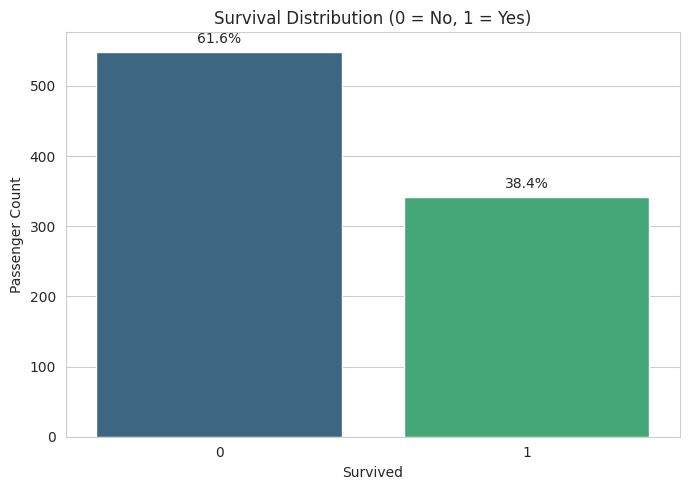

In [15]:
plt.figure(figsize=(7, 5))
ax = sns.countplot(data=df, x='survived', palette='viridis', hue='survived', legend=False)
plt.title('Survival Distribution (0 = No, 1 = Yes)')
plt.xlabel('Survived')
plt.ylabel('Passenger Count')

# Add percentage labels
total = len(df)
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{(height/total)*100:.1f}%',
                (p.get_x() + p.get_width() / 2, height),
                ha='center', va='bottom', fontsize=10, xytext=(0, 4),
                textcoords='offset points')

plt.tight_layout()
plt.show()

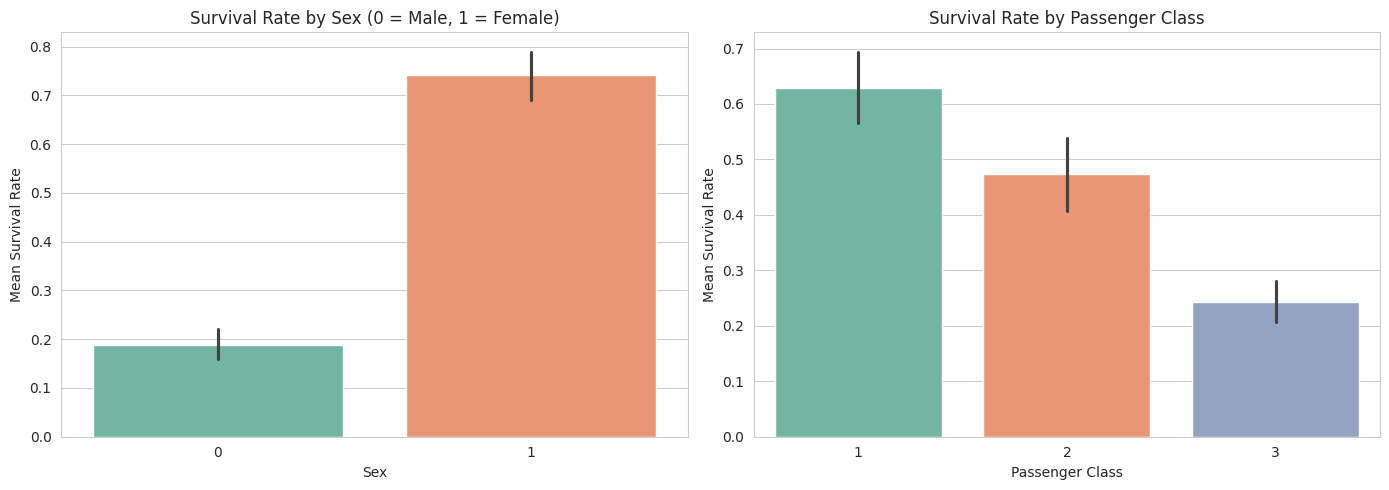

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=df, x='sex', y='survived', ax=axes[0], palette='Set2', hue='sex', legend=False)
axes[0].set_title('Survival Rate by Sex (0 = Male, 1 = Female)')
axes[0].set_xlabel('Sex')
axes[0].set_ylabel('Mean Survival Rate')

sns.barplot(data=df, x='pclass', y='survived', ax=axes[1], palette='Set2', hue='pclass', legend=False)
axes[1].set_title('Survival Rate by Passenger Class')
axes[1].set_xlabel('Passenger Class')
axes[1].set_ylabel('Mean Survival Rate')

plt.tight_layout()
plt.show()

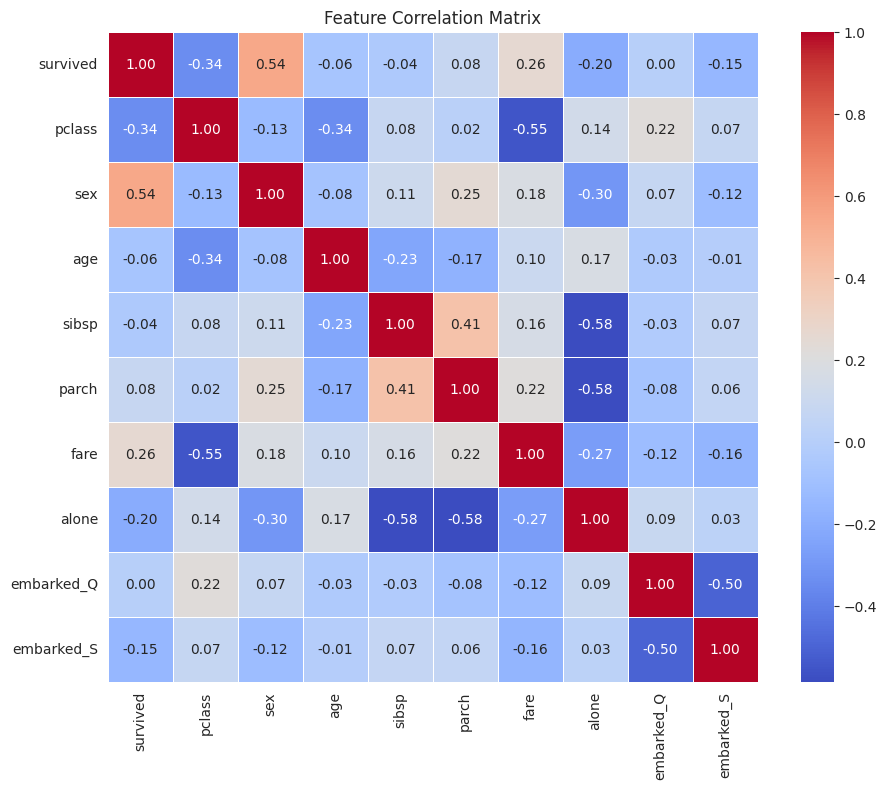

In [17]:
corr = df.corr(numeric_only=True)
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', square=True, linewidths=0.4)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

## Modeling Setup
In this section, we split the data into train and test sets, scale continuous features, and train a baseline logistic regression model with class balancing.

In [18]:
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler

# Define features and target
X = df.drop(columns=['survived'])
y = df['survived']

# Train/test split with stratification
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print('Target distribution (train):')
print(y_train.value_counts(normalize=True).rename('proportion').round(3))

# Scale continuous features only
scaler = StandardScaler()
cols_to_scale = ['age', 'fare']

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[cols_to_scale] = scaler.fit_transform(X_train[cols_to_scale])
X_test_scaled[cols_to_scale] = scaler.transform(X_test[cols_to_scale])

print('\nPrepared train shape:', X_train_scaled.shape)
print('Prepared test shape:', X_test_scaled.shape)

Target distribution (train):
survived
0    0.617
1    0.383
Name: proportion, dtype: float64

Prepared train shape: (712, 9)
Prepared test shape: (179, 9)


In [19]:
from sklearn.linear_model import LogisticRegression

# Train logistic regression baseline
model = LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced')
model.fit(X_train_scaled, y_train)

# Predictions
y_pred = model.predict(X_test_scaled)
y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]

# 5-fold CV score on training split (AUC)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_auc = cross_val_score(model, X_train_scaled, y_train, cv=cv, scoring='roc_auc')

print(f'Cross-validated ROC-AUC (train, mean +/- std): {cv_auc.mean():.3f} +/- {cv_auc.std():.3f}')

Cross-validated ROC-AUC (train, mean +/- std): 0.856 +/- 0.021


## Model Evaluation
We evaluate classification quality using threshold-based metrics, confusion matrix, ROC-AUC, and Precision-Recall curves to better understand performance under class imbalance.

Test set metrics:
Accuracy:  0.793
Precision: 0.722
Recall:    0.754
F1-score:  0.738
ROC-AUC:   0.851
PR-AUC:    0.796

Classification report:
                 precision    recall  f1-score   support

Did Not Survive       0.84      0.82      0.83       110
       Survived       0.72      0.75      0.74        69

       accuracy                           0.79       179
      macro avg       0.78      0.79      0.78       179
   weighted avg       0.80      0.79      0.79       179



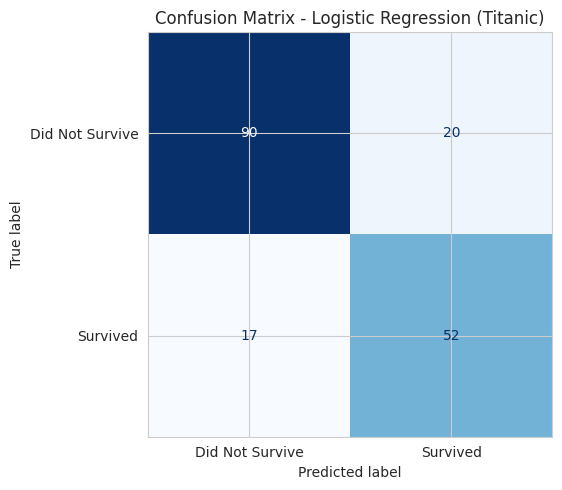

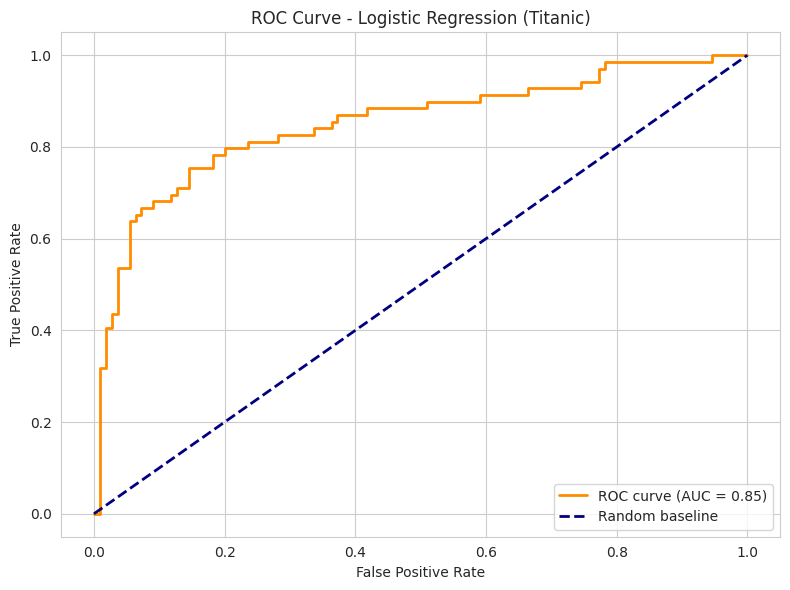

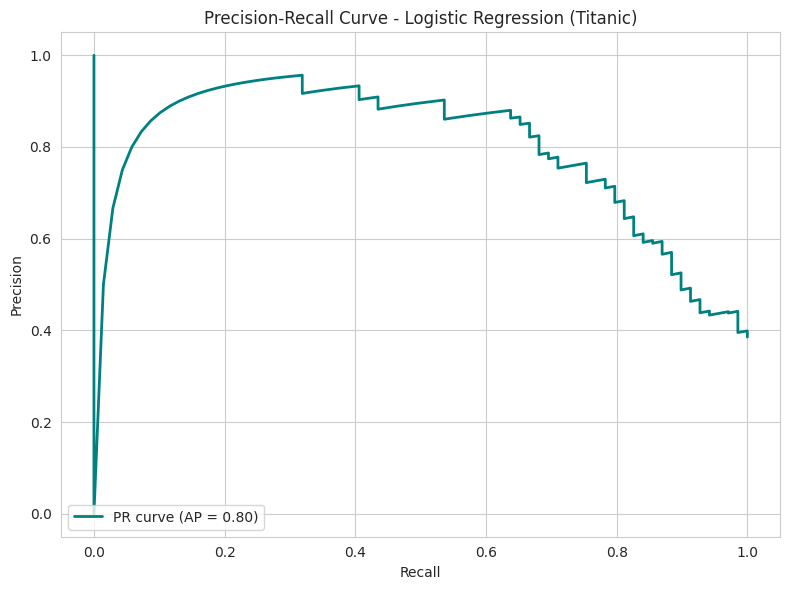

In [20]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    average_precision_score,
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    ConfusionMatrixDisplay
)

# Core metrics
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)
ap = average_precision_score(y_test, y_pred_proba)

print('Test set metrics:')
print(f'Accuracy:  {acc:.3f}')
print(f'Precision: {prec:.3f}')
print(f'Recall:    {rec:.3f}')
print(f'F1-score:  {f1:.3f}')
print(f'ROC-AUC:   {roc_auc:.3f}')
print(f'PR-AUC:    {ap:.3f}\n')

print('Classification report:')
print(classification_report(y_test, y_pred, target_names=['Did Not Survive', 'Survived']))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Did Not Survive', 'Survived'])
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Confusion Matrix - Logistic Regression (Titanic)')
plt.tight_layout()
plt.show()

# ROC curve
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random baseline')
plt.title('ROC Curve - Logistic Regression (Titanic)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

# Precision-Recall curve
precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_pred_proba)
plt.figure(figsize=(8, 6))
plt.plot(recall_vals, precision_vals, color='teal', lw=2, label=f'PR curve (AP = {ap:.2f})')
plt.title('Precision-Recall Curve - Logistic Regression (Titanic)')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.legend(loc='lower left')
plt.tight_layout()
plt.show()